In [ ]:
!pip install gpflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 392.9/392.9 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.8/45.8 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 111.0/111.0 kB 7.8 MB/s eta 0:00:00


Mass-Spring-Damper System
$$ mÿ + cẏ + ky = F(t)$$

Aproximación
$$ mÿ + cẏ + ky = F_{known}(t)$$
* $F_{known}(t)$  ó $g(t)$ Fuerza latente (modelada como GP)

In [ ]:
#1. System and data
import torch
import gpytorch
import matplotlib.pyplot as plt

# Parámetros del sistema
m = 1.0    # Masa
c = 0.5    # Coeficiente de amortiguamiento
k = 2.0    # Constante del resorte

# Tiempo
t = torch.linspace(0, 10, 100)
dt = t[1] - t[0]

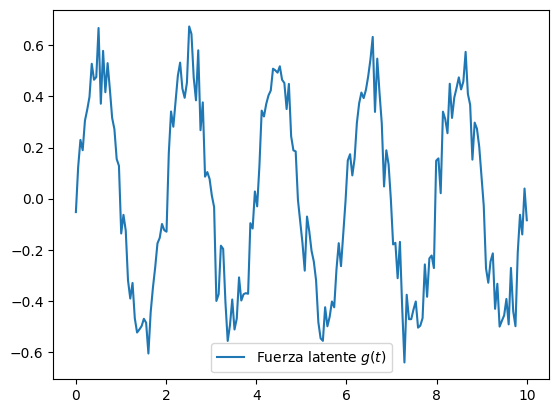

In [ ]:
#2. Fuerza latente con GP

# Función de fuerza latente (ejemplo: senoidal + ruido)
def latent_force(t):
    return 0.5 * np.sin(2 * np.pi * 0.5 * t) + 0.1 * np.random.randn(len(t))

# Solución numérica de la EDO (usando diferencias finitas)
y = np.zeros_like(t)
dy_dt = np.zeros_like(t)
g = latent_force(t)

for i in range(1, len(t)):
    d2y_dt2 = (f[i] - c * dy_dt[i-1] - k * y[i-1]) / m
    dy_dt[i] = dy_dt[i-1] + d2y_dt2 * dt
    y[i] = y[i-1] + dy_dt[i] * dt


plt.plot(t, g, label="Fuerza latente $g(t)$")
plt.legend()
plt.show()

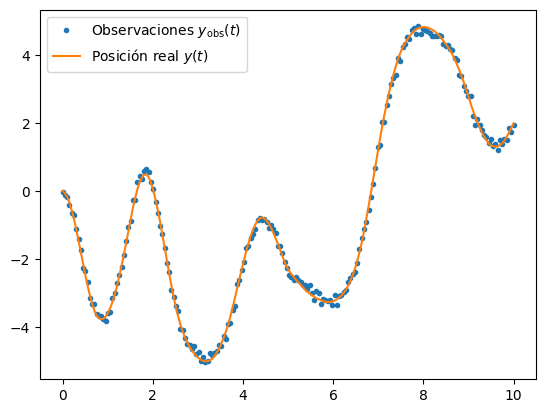

In [ ]:
#3. simulacion del sistema

# Añadir ruido a las observaciones
y_noise = y + 0.1 * np.random.randn(len(t))

plt.plot(t, y_noise, ".", label="Observaciones $y_{\\text{obs}}(t)$")
plt.plot(t, y, label="Posición real $y(t)$")
plt.legend()
plt.show()

La función de Green del sistema, que representa la respuesta del sistema a un impulso unitario en el tiempo tau. Es la solución fundamental de la ecuación diferencial homogénea asociada al sistema.

Ecuación y parámetros:

$$
G(t, \tau)=\frac{1}{m \omega_d} e^{-\gamma(t-\tau)} \sin \left(\omega_d(t-\tau)\right)
$$

- $\gamma=\frac{c}{2 m}$ : Coeficiente de amortiguamiento crítico.
- $\omega_n=\sqrt{\frac{k}{m}}$ : Frecuencia natural no amortiguada.
- $\omega_d=\sqrt{\omega_n^2-\gamma^2}$ : Frecuencia natural amortiguada.

Uso en LFMs:
La función de Green permite expresar la solución de la ecuación diferencial como una convolución entre la fuerza latente $f(t)$ y $G(t, \tau)$.

2. Función compute_displacement(f, t, m, c, k)

Propósito:
Calcular el desplazamiento $y(t)$ del sistema mediante la convolución discreta de la fuerza latente $f(t)$ con la función de Green.

Fórmula de convolución:

$$
y(t)=\int_0^t G(t, \tau) f(\tau) d \tau \approx \sum_{j=0}^i G\left(t_i, \tau_j\right) f\left(\tau_j\right) \Delta t
$$

- $\Delta t=t[1]-t[0]$ : Paso temporal.
- Se suma la contribución de la fuerza $f\left(\tau_j\right)$ en cada instante $\tau_j$ hasta $t_i$.

Implementación:
- Itera sobre cada tiempo $t_i$.
- Para cada $t_i$, suma las contribuciones de $f\left(\tau_j\right)$ multiplicadas por $G\left(t_i, \tau_j\right)$ y $\Delta t$.

In [ ]:
# 4. Definiendo el modelo de fuerza latente
import gpflow
from gpflow.kernels import RBF
from gpflow.models import GPR

# Función de Green para el sistema (solución homogénea)
def green_function(t, tau, m, c, k):
    gamma = c / (2 * m)
    omega_n = np.sqrt(k / m)
    # omega_d = np.sqrt(omega_n**2 - gamma**2) # Error si c >= 2√(mk)
    omega_d = np.sqrt(omega_n**2 - gamma**2 + 1e-8)

    return (1 / (m * omega_d)) * np.exp(-gamma * (t - tau)) * np.sin(omega_d * (t - tau))

# Convolución de la fuerza latente con la función de Green
def compute_displacement(f, t, m, c, k):
    y_pred = np.zeros_like(t)
    for i in range(len(t)):
        y_pred[i] = np.sum([green_function(t[i], tau, m, c, k) * f[j] * (t[1]-t[0])
                            for j, tau in enumerate(t[:i+1])])
    return y_pred

In [ ]:
#5. COnfigurar el modelo train test, kernel
import tensorflow as tf

# Datos observados (usamos solo 20 puntos para entrenar)
train_indices = np.random.choice(len(t), 20, replace=False)
X_train = tf.convert_to_tensor(t[train_indices].reshape(-1, 1), dtype=tf.float64)
Y_train = tf.convert_to_tensor(y_noise[train_indices].reshape(-1, 1), dtype=tf.float64)

# Configurar kernel y modelo
kernel_f = RBF(lengthscales=0.5, variance=0.1)
model_f = GPR(data=(X_train, Y_train), kernel=kernel_f)

# Forzar parámetros a float64 para evitar problemas
gpflow.utilities.set_trainable(model_f.likelihood.variance, False)
model_f.likelihood.variance.assign(0.01)


<tf.Variable 'UnreadVariable' shape=() dtype=float64, numpy=-4.600266525158521>

In [ ]:
#6. Optimizar hiperparámetros
opt = gpflow.optimizers.Scipy()
opt.minimize(model_f.training_loss, model_f.trainable_variables)

  message: CONVERGENCE: NORM OF PROJECTED GRADIENT <= PGTOL
  success: True
   status: 0
      fun: 23.983902981168683
        x: [ 8.030e-02  8.601e+00]
      nit: 17
      jac: [ 4.953e-06 -1.623e-08]
     nfev: 18
     njev: 18
 hess_inv: <2x2 LbfgsInvHessProduct with dtype=float64>

<Figure size 1200x600 with 0 Axes>

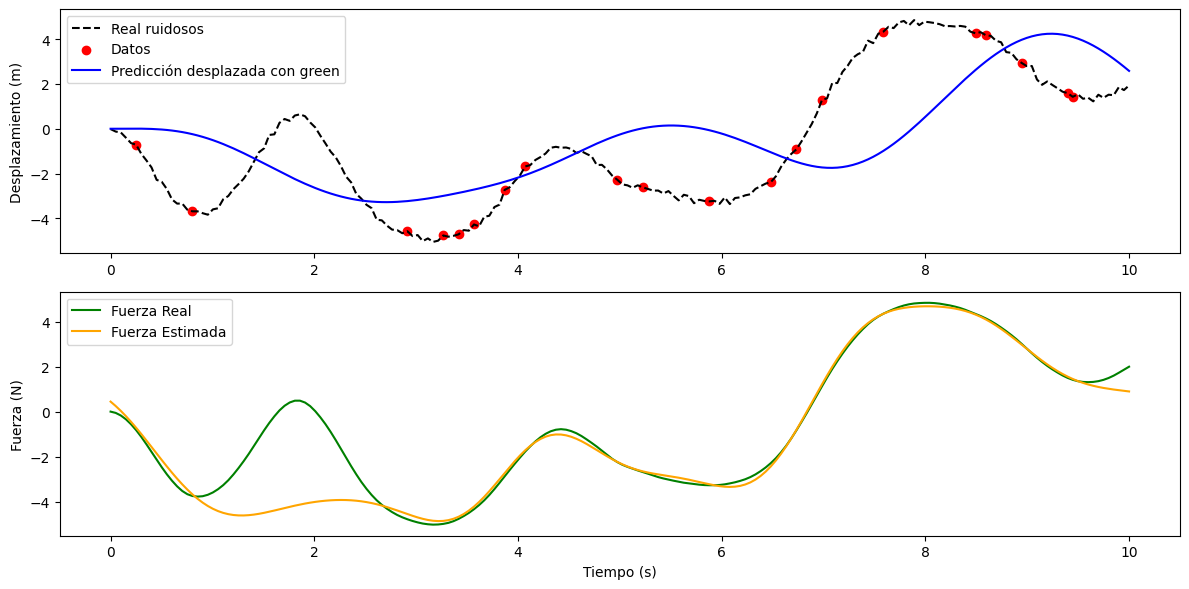

In [ ]:
#7. Inferencia
X_test = tf.convert_to_tensor(t.reshape(-1, 1), dtype=tf.float64)
f_pred, _ = model_f.predict_f(X_test)


# Calcular el desplazamiento predicho usando la fuerza estimada
y_pred = compute_displacement(f_pred.numpy().flatten(), t, m=1.0, c=0.5, k=2.0)
# y_pred, _ = model_f.predict_y(X_test)

plt.figure(figsize=(12, 6))

# Observaciones vs Predicciones
plt.figure(figsize=(12, 6))
plt.subplot(2, 1, 1)
plt.plot(t, y_noise, label="Real ruidosos", linestyle="--", color="black")
plt.scatter(X_train.numpy(), Y_train.numpy(), color="red", label="Datos")
plt.plot(t, y_pred, label="Predicción desplazada con green", color="blue")
plt.ylabel("Desplazamiento (m)")
plt.legend()

plt.subplot(2, 1, 2)
plt.plot(t, y, label="Fuerza Real", color="green")
plt.plot(t, f_pred.numpy(), label="Fuerza Estimada", color="orange")
plt.xlabel("Tiempo (s)")
plt.ylabel("Fuerza (N)")
plt.legend()

plt.tight_layout()
plt.show()

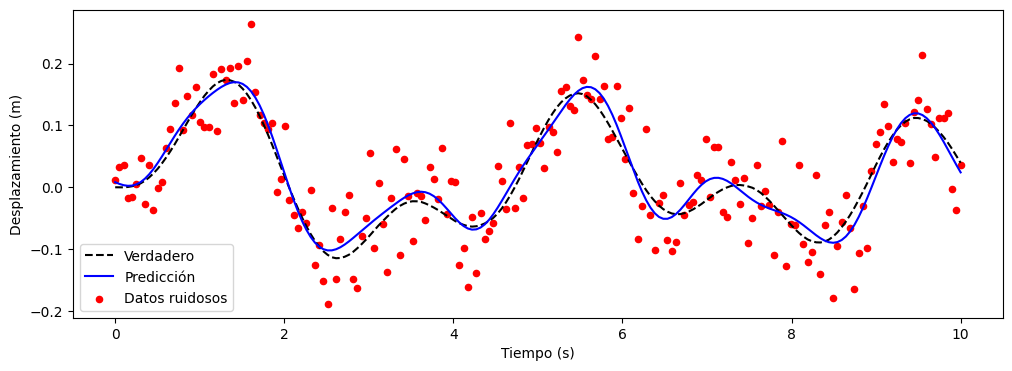

In [ ]:
#Inferencia:
# Calcular desplazamiento con la fuerza aprendida

# Generar datos sintéticos (ejemplo)
t = np.linspace(0, 10, 200)
y_true = compute_displacement(f=latent_force(t), t=t, m=1.0, c=0.4, k=2.0)
y_train = y_true + 0.05 * np.random.randn(len(t))  # Añadir ruido
# Entrenar el modelo GP (usando y_train)
model_f = GPR(data=(t.reshape(-1, 1), y_train.reshape(-1, 1)), kernel=RBF())
opt = gpflow.optimizers.Scipy()
opt.minimize(model_f.training_loss, model_f.trainable_variables)



# Predecir y calcular desplazamiento
f_pred, _ = model_f.predict_f(t.reshape(-1, 1))
y_pred = compute_displacement(f_pred.numpy().flatten(), t, m=1.0, c=0.5, k=2.0)



# Graficar
plt.figure(figsize=(12, 4))
plt.plot(t, y_true, "--k", label="Verdadero")
plt.plot(t, f_pred, "b", label="Predicción")
plt.scatter(t, y_train, c="r", s=20, label="Datos ruidosos")
plt.xlabel("Tiempo (s)"); plt.ylabel("Desplazamiento (m)")
plt.legend()
plt.show()

La función de Green
$G(t,τ)$ codifica la respuesta física del sistema (masa-resorte-amortiguador) a una fuerza impulsiva.

Es una propiedad fija del sistema si los parámetros m, c, k son conocidos y constantes.

No se optimiza: Su forma depende únicamente de los parámetros físicos.

# Hibrido, optimizando parametros m, c, k (desconocidos)

**¿Por qué no se ajusta $G(t)$ junto al GP?**

* Caso 1: Si m,c,k son conocidos, $G(t)$ es fija y el modelo solo aprende
$f(t)$.

* Caso 2: Si m,c,k son desconocidos, se pueden incluir como parámetros a optimizar, y $G(t)$ se vuelve parte del modelo híbrido (físico + GP).

In [270]:
import gc
gc.collect()

20892

Parámetros inferidos:
m = 0.360 (real = 1.0)
c = 1.138 (real = 0.4)
k = 2.521 (real = 2.0)


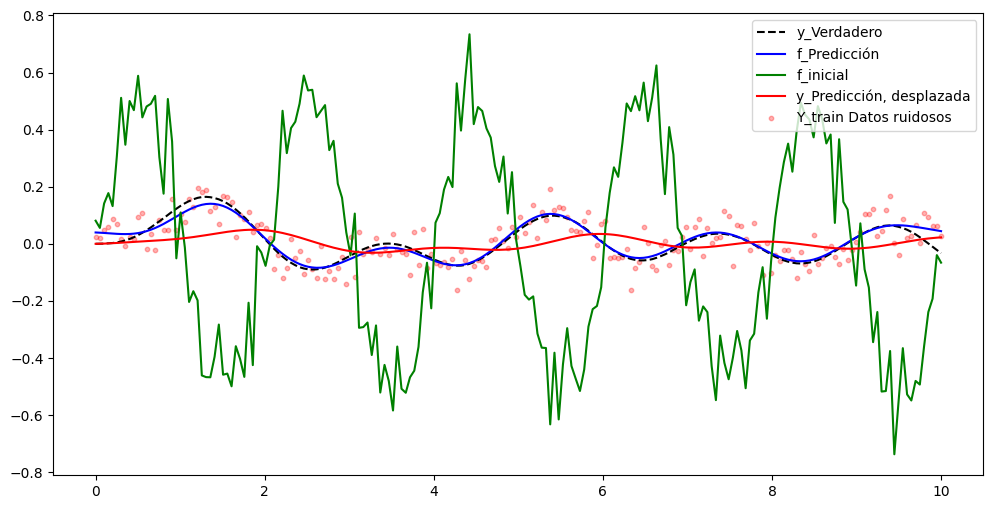

In [282]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import gpflow
from gpflow.kernels import RBF
from gpflow.models import GPModel
from gpflow.utilities import positive
from gpflow.likelihoods import Gaussian

# 1. Generar datos sintéticos (parámetros REALES desconocidos)
m_true = 1.0
c_true = 0.4
k_true = 2.0

def latent_force(t):
    return 0.5 * np.sin(2 * np.pi * 0.5 * t) + 0.1 * np.random.randn(len(t))

t = np.linspace(0, 10, 200).astype(np.float64)
f = latent_force(t).astype(np.float64)

# Simular sistema con parámetros reales
y_true = np.zeros_like(t, dtype=np.float64)
dy_dt = np.zeros_like(t, dtype=np.float64)
dt = t[1] - t[0]

for i in range(1, len(t)):
    d2y_dt2 = (f[i] - c_true*dy_dt[i-1] - k_true*y_true[i-1]) / m_true
    dy_dt[i] = dy_dt[i-1] + d2y_dt2*dt
    y_true[i] = y_true[i-1] + dy_dt[i]*dt

y_train = y_true + 0.05 * np.random.randn(len(t)).astype(np.float64)


# 2. Definir parámetros físicos y funciones

# m = gpflow.Parameter(1.0, transform=positive(), dtype=tf.float64)
# c = gpflow.Parameter(0.4, transform=positive(), dtype=tf.float64)
# k = gpflow.Parameter(2.0, transform=positive(), dtype=tf.float64)
# Inicialización aleatoria positiva para m, c, k
m = gpflow.Parameter(np.abs(np.random.normal(loc=1.0, scale=0.5)), transform=positive(), dtype=tf.float64)
c = gpflow.Parameter(np.abs(np.random.normal(loc=0.5, scale=0.3)), transform=positive(), dtype=tf.float64)
k = gpflow.Parameter(np.abs(np.random.normal(loc=2.0, scale=0.5)), transform=positive(), dtype=tf.float64)


#Función de Green (resolución analítica de ODE con delta)
def green_function(t, tau):
    gamma = c / (2 * m)
    omega_n = tf.sqrt(k / m)
    omega_d = tf.sqrt(omega_n**2 - gamma**2 + 1e-8)
    return (1 / (m * omega_d)) * tf.exp(-gamma * (t - tau)) * tf.sin(omega_d * (t - tau))

#Convolución: y(t) = ∫ G(t - τ) f(τ) dτ
def compute_displacement(f_latent, t):
    dt = t[1] - t[0]
    n = tf.shape(t)[0]
    y_pred = tf.TensorArray(dtype=tf.float64, size=n)

    def body(i, y_array):
        tau = t[:i+1]
        ti = t[i]
        ti_repeated = tf.fill([i+1], ti)
        g = green_function(ti_repeated, tau)
        fi = f_latent[:i+1]
        yi = tf.reduce_sum(g * fi) * dt
        y_array = y_array.write(i, yi)
        return i + 1, y_array

    _, result = tf.while_loop(
        lambda i, _: i < tf.shape(t)[0],
        body,
        [tf.constant(0), y_pred]
    )

    return result.stack()





# 3. Entrenamiento del modelo
X_train = t.reshape(-1, 1).astype(np.float64)
Y_train = y_train.reshape(-1, 1).astype(np.float64)

kernel = RBF(lengthscales=0.5, variance=0.1)
model = gpflow.models.GPR(data=(X_train, Y_train), kernel=kernel)



# 4. Optimización conjunta
# trainable_variables = model.trainable_variables + [m, c, k]
opt = gpflow.optimizers.Scipy()
opt.minimize(model.training_loss, model.trainable_variables, options=dict(maxiter=1000))

# 5. Predicciones y gráficos
f_mean, _ = model.predict_f(X_train)
y_pred = compute_displacement(f_mean.numpy().flatten(), t)


# 6. Ajuste conjunto (si deseas refinar m, c, k)
# -------------------------------
def total_loss():
    f_mean, _ = model.predict_f(X_train)
    y_model = compute_displacement(tf.squeeze(f_mean), tf.constant(t, dtype=tf.float64))
    physics_loss = tf.reduce_mean((y_model - y_train)**2)
    gp_loss = model.training_loss()
    return gp_loss + 1.0 * physics_loss  # puedes ajustar el peso

trainable = list(model.trainable_variables) + [v for p in [m, c, k] for v in p.trainable_variables]
opt.minimize(total_loss, trainable, options=dict(maxiter=500))

print("Parámetros inferidos:")
print(f"m = {m.numpy():.3f} (real = {m_true})")
print(f"c = {c.numpy():.3f} (real = {c_true})")
print(f"k = {k.numpy():.3f} (real = {k_true})")

f_mean, _ = model.predict_f(X_train)
y_pred = compute_displacement(f_mean.numpy().flatten(), t)

plt.figure(figsize=(12, 6))
plt.plot(t, y_true, 'k--', label="y_Verdadero")
plt.plot(t, f_mean, 'b', label="f_Predicción")
plt.plot(t, f, 'g', label="f_inicial")
plt.plot(t, y_pred, 'r', label="y_Predicción, desplazada")
plt.scatter(t, y_train, c='r', s=10, alpha=0.3, label="Y_train Datos ruidosos")
plt.legend()
plt.show()